In [2]:
import casadi
import numpy as np
import minsnap_trajectories as ms
import matplotlib.pyplot as plt
from plan_multi_bicycle import MPC_CBF_Bicycle, dm_to_array, animate
from plan_poly import plan_poly_traj
%load_ext autoreload
%autoreload 2

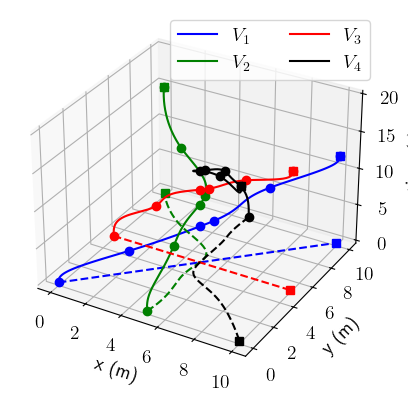

In [3]:
fig = plt.figure()
ax = plt.axes(projection='3d')


## waypoint = [t , p_x , p_y]
aircraft_1_wp = np.array([[0.0, 0.0, 0.0],
                          [3.0, 2.5, 2.5],
                          [5.0, 5.0, 5.0],
                          [5.5, 5.5, 5.5],
                          [9.0, 7.5, 7.5],
                          [12.0, 10.0, 10.0]
                          ])

aircraft_2_wp = np.array([[0.0, 5.0, 0.0],
                          [5.5, 5.0, 2.5],
                          [8.0, 5.0, 5.0],
                          [8.5, 5.0, 5.5],
                          [11.0, 2.5, 7.5],
                          [15.0, 0.0, 10.0]
                          ])
aircraft_3_wp = np.array([[0.0, 0.0, 5.0],
                          [6.0, 2.5, 5.0],
                          [10.0, 5.0, 5.0],
                          [10.5, 5.5, 5.0],
                          [13.0, 7.5, 5.0],
                          [16.0, 10.0, 5.0]
                          ])

aircraft_4_wp = np.array([[0.0, 5.0, 10.0],
                          [9.5, 5.0, 7.5],
                          [12.0, 5.0, 5.5],
                          [12.5, 5.0, 5.0],
                          [16.5, 7.5, 2.5],
                          [20.0, 10.0, 0.0]
                          ])

wps = np.array([aircraft_1_wp, aircraft_2_wp, aircraft_3_wp, aircraft_4_wp])
lbls= ['$V_1$', '$V_2$', '$V_3$', '$V_4$']
colors = ['b', 'g', 'r', 'k']
wp_start = ['o', 'o', 'o', 'o']
wp_goal = ['s', 's', 's', 's']

n_agents = 4
trajs = []
for i in range(n_agents):
    boundary_cdn = []
    for j in range(wps[i].shape[0]):
        boundary_cdn += [
            ms.Waypoint(
                time=wps[i][j,0],
                position=wps[i][j,1:3],
            )
        ]
 
    t, pos, vel = plan_poly_traj(boundary_cdn, wps[i][-1,0], 0.1)
    ax.plot3D(pos[:, 0], pos[:, 1], t, color = colors[i], label=lbls[i])
    ax.plot(pos[:, 0], pos[:, 1], '--', color = colors[i])
    
    position_waypoints = np.array([it.position for it in boundary_cdn])
    time_waypoints = np.array([it.time for it in boundary_cdn])
    ax.plot(
        position_waypoints[:, 0],
        position_waypoints[:, 1],
        time_waypoints,
        wp_start[i],
        color = colors[i]
    )
    ax.plot(
        position_waypoints[-1, 0],
        position_waypoints[-1, 1],
        wp_goal[i],
        color = colors[i]
    )
    ax.plot(
        position_waypoints[-1, 0],
        position_waypoints[-1, 1],
        time_waypoints[-1],
        wp_goal[i],
        color = colors[i]
    )
    traj = {}
    traj['x'] = pos[:, 0]
    traj['y'] = pos[:, 1]
    traj['theta'] = np.arctan2(
                vel[:, 1], vel[:, 0]
            )
    traj['v'] = np.linalg.norm(vel[:,:], axis = 1)

    trajs.append(traj)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("time (s)")
ax.legend(loc="upper right", ncol = 2)
plt.grid()
plt.show()

100%|██████████| 200/200 [00:08<00:00, 24.04it/s]


avg_vel_var 0.3147653797525018
avg_acc_var 0.11491601293332034


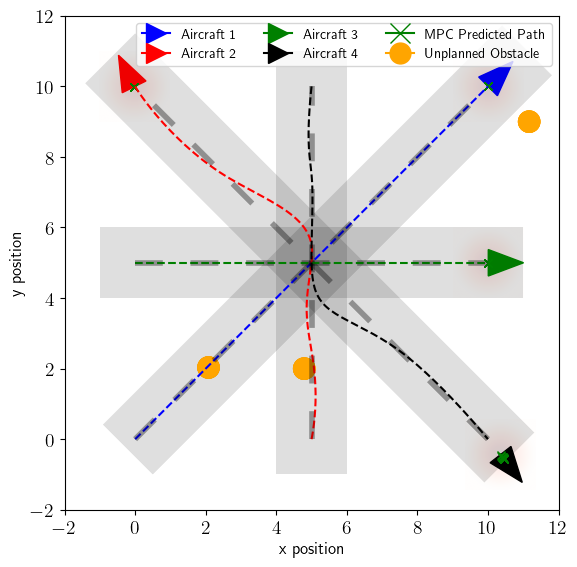

In [4]:
# Consider all homogenous agents with identical parameters
Q_x = 10
Q_y = 10
Q_theta = 5
Q_v = 5
R_a = 0.01
R_delta = 0.01

dt = 0.1
N = 15

L = 1
a_lim = [-0.5, 0.5]
delta_lim = [-casadi.pi/6, casadi.pi/6]
Q = [Q_x, Q_y, Q_theta, Q_v]
R = [R_a, R_delta]

n_agents = 4


agents_init_state = np.array([[0.0, 0.0, np.pi/4, 0.0], [5.0, 0.0, np.pi/2, 0.0], [0.0, 5.0, 0, 0.0], [5.0, 10.0, -np.pi/2, 0.0]])
agents_goal_state = np.array([[10.0, 10.0, np.pi/4, 0.0], [0.0, 10.0, -3*np.pi/4, 0.0], [10.0, 5.0, 0, 0.0], [10.0, 10.0, -np.pi/4, 0.0]])
obstacles = [(8, 2), (8, 9), (4,2)]
obs_list = [obstacles]

t0_list = [0 for i in range(n_agents)]
agents = [MPC_CBF_Bicycle(agents_init_state[i], n_agents-1, dt, N, a_lim, delta_lim, L, Q, R, obstacles = obstacles, obs_diam=0.4, alpha=0.15, cbf_const=True) 
          for i in range(n_agents)]

state_0_list = [casadi.DM([
    agents_init_state[i][0], 
    agents_init_state[i][1], 
    agents_init_state[i][2],
    agents_init_state[i][3]]) for i in range(n_agents)]
u0_list = [casadi.DM.zeros((agents[i].n_controls, N)) for i in range(n_agents)]
X0_list = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]

u_list = [casadi.DM.zeros((agents[i].n_controls, N)) for i in range(n_agents)]
X_pred_list = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]
agents_state_list = [dm_to_array(X0_list[i]) for i in range(n_agents)]
agents_control_list = [dm_to_array(u0_list[i][:, 0]) for i in range(n_agents)]
ref_state_list = [np.array([
    trajs[j]['x'][:-1].tolist(),
    trajs[j]['y'][:-1].tolist(), 
    trajs[j]['theta'][:-1].tolist(),
    trajs[j]['v'][:-1].tolist()]).T
    for j in range(n_agents)]


max_iter = 200
count = 0
from tqdm import tqdm
for t in tqdm(range(max_iter)):
    #print(t)
    # Construct a list of neighbor states for all robots
    agent_states = np.array([agents[i].states for i in range(n_agents)])
    #print(agent_states[0][2], trajs[j]['theta'][t])
    #obstacles = [(4 + t*0.004, 4 + t*0.016), (8+t*0.016, 9)]
    obstacles = [(2 + t*0.0004, 2 + t*0.00016), (8+t*0.016, 9), (4+t*0.004, 2)]
    obs_list.append(obstacles)
    for j in range(n_agents):
        # if np.sqrt((agent_states[j][0] - wps[j][-1,1])**2 +(agent_states[j][1] - wps[j][-1,2])**2) < 1.0:
        #     count+=1

        neighbor_states = []
        for k,agent_state in enumerate(agent_states):
            if k !=j :
                neighbor_states.append(agent_state)
        neighbor_states = np.array(neighbor_states)
        u_list[j], X_pred_list[j] = agents[j].solve(X0_list[j], u0_list[j], ref_state_list[j], t, neighbor_states, obstacles)
    for j in range(n_agents):
        agents_state_list[j] = np.dstack((agents_state_list[j], dm_to_array(X_pred_list[j])))
        agents_control_list[j] = np.dstack((agents_control_list[j], dm_to_array(u_list[j][:, 0])))
        t0_list[j], X0_list[j], u0_list[j] = agents[j].shift_timestep(dt, t0_list[j], X_pred_list[j], u_list[j])

anim_params = {
    'n_agents': n_agents,
    'ref_state_list': ref_state_list,
    'agents_init_state':agents_init_state,
    'agents_state_list':agents_state_list,
    'agents_control_list':agents_control_list,
    'num_frames':max_iter,
    'max_iter':max_iter,
    'pred_horizon':N,
    'save': False,
    'file_name':'collision_avoid.mp4',
    'obs_list': obs_list,

}


vel_var = np.zeros(4)
for i in range(n_agents):
    vel_var[i] = np.var(agents_state_list[i][3, 0, 30:-30])
print('avg_vel_var', np.mean(vel_var))

acc_var = np.zeros(4)
for i in range(n_agents):
    acc_var[i] = np.var(agents_control_list[i][0, 0, 30:-30])

print('avg_acc_var', np.mean(acc_var))

sim = animate(anim_params)
from IPython.display import HTML
HTML(sim.to_html5_video())